# JOUR 3 — APRÈS-MIDI  
## Apprentissage non supervisé : segmentation, PCA, t-SNE et anomalies

### Dataset : UCI Online Retail II
Nous utilisons ici une **vraie base transactionnelle** de commerce en ligne britannique.

Le notebook tente de charger :
- `online_retail_II.xlsx` / `online_retail_II.csv` dans le dossier courant ;
- ou `/mnt/data/...`.

> Le fichier volumineux n’est pas intégré au notebook. Téléchargez-le depuis la source officielle UCI avant la séance.

### Fil conducteur
Transactions → table clients → features comportementales → scaling → K-means → CAH → DBSCAN → PCA → t-SNE → anomalies → interprétation métier.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

candidates = [
    Path(r"C:\Users\amous\Downloads\online+retail+ii\online_retail_II.xlsx")
]

path = next((p for p in candidates if p.exists()), None)

if path is None:
    raise FileNotFoundError(
        "Fichier introuvable. Vérifiez le chemin et le nom du fichier."
    )

if path.suffix.lower() == ".xlsx":
    sheets = pd.read_excel(path, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
else:
    df = pd.read_csv(path)

print("Fichier :", path)
print("Dimensions :", df.shape)
display(df.head())

Fichier : C:\Users\amous\Downloads\online+retail+ii\online_retail_II.xlsx
Dimensions : (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Explication
La donnée est au niveau **transaction / ligne de facture**.  
K-means ne doit pas directement segmenter des lignes de facture si notre question est : « quels types de clients avons-nous ? »

Nous devons donc construire une **table client** : une ligne = un client.


# 1. Audit et normalisation des noms de colonnes


In [6]:
print(df.columns.tolist())
display(df.isna().sum().sort_values(ascending=False).head(10))

# Harmoniser quelques variantes de noms rencontrées selon le fichier
rename = {
    "Invoice":"InvoiceNo",
    "Customer ID":"CustomerID",
    "Price":"UnitPrice"
}
df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})

required = ["InvoiceNo","Quantity","InvoiceDate","UnitPrice","CustomerID"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes attendues absentes : {missing}")


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


Customer ID    243007
Description      4382
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

# 2. Nettoyage factuel et création du montant

Décisions :
- `CustomerID` manquant : impossible d’agréger proprement au niveau client → exclu de la segmentation client ;
- quantité ou prix non positifs : à analyser séparément comme retours/annulations, pas comme achat positif ;
- montant ligne = `Quantity × UnitPrice`.

### Exemple développeur
C’est une transformation de **granularité** : exactement comme transformer des logs HTTP en une table « une ligne par utilisateur » avant un modèle comportemental.


In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["is_cancel"] = df["InvoiceNo"].str.upper().str.startswith("C") | (df["Quantity"] < 0)
df["LineAmount"] = df["Quantity"] * df["UnitPrice"]

print("Transactions annulées/retours :", int(df["is_cancel"].sum()))
print("CustomerID manquants :", int(df["CustomerID"].isna().sum()))


Transactions annulées/retours : 22951
CustomerID manquants : 243007


# 3. Construire des features clients

Nous créons notamment :
- **Recency** : jours depuis le dernier achat ;
- **Frequency** : nombre de factures positives distinctes ;
- **Monetary** : chiffre d’affaires positif cumulé ;
- **AvgBasket** : montant moyen par facture ;
- **TotalQuantity** : quantité positive achetée ;
- **ReturnRate** : part des lignes correspondant à des retours/annulations.

Ces variables décrivent un comportement et sont beaucoup plus pertinentes que des identifiants bruts.


In [9]:
valid_customers = df.dropna(subset=["CustomerID"]).copy()
valid_customers["CustomerID"] = valid_customers["CustomerID"].astype(str)

positive = valid_customers[
    (~valid_customers["is_cancel"]) &
    (valid_customers["Quantity"] > 0) &
    (valid_customers["UnitPrice"] > 0)
].copy()

snapshot = positive["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = positive.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate","max"),
    Frequency=("InvoiceNo","nunique"),
    Monetary=("LineAmount","sum"),
    TotalQuantity=("Quantity","sum")
)
rfm["Recency"] = (snapshot - rfm["LastPurchase"]).dt.days

invoice_totals = positive.groupby(["CustomerID","InvoiceNo"])["LineAmount"].sum()
avg_basket = invoice_totals.groupby("CustomerID").mean().rename("AvgBasket")

return_rate = (valid_customers.groupby("CustomerID")["is_cancel"].mean()
               .rename("ReturnRate"))

customers = rfm.join(avg_basket).join(return_rate).drop(columns="LastPurchase")
customers = customers.replace([np.inf,-np.inf], np.nan).dropna()

print("Nombre de clients :", len(customers))
display(customers.describe().T.round(2))
display(customers.head())


Nombre de clients : 5878


,count,mean,std,min,25%,50%,75%,max
Frequency,5878.0,6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,5878.0,3018.62,14737.73,2.95,348.76,898.92,2307.09,608821.65
TotalQuantity,5878.0,1821.40,8963.01,1.00,190.00,491.50,1376.00,367193.00
Recency,5878.0,201.33,209.34,1.00,26.00,96.00,380.00,739.00
AvgBasket,5878.0,391.73,1215.07,2.95,181.65,285.07,420.57,84236.25
ReturnRate,5878.0,0.03,0.07,0.00,0.00,0.00,0.02,0.75


,Frequency,Monetary,TotalQuantity,Recency,AvgBasket,ReturnRate
CustomerID,,,,,,
12346.0,12,77556.46,74285,326,6463.038333,0.291667
12347.0,8,5633.32,3286,2,704.165000,0.000000
12348.0,5,2019.40,2714,75,403.880000,0.000000
12349.0,4,4428.69,1624,19,1107.172500,0.027778
12350.0,1,334.40,197,310,334.400000,0.000000


### Discussion
Pourquoi ne pas inclure `CustomerID` comme variable numérique ?  
Parce qu’un identifiant n’exprime pas une distance comportementale : le client 5000 n’est pas « deux fois » le client 2500.


# 4. Scaling

K-means, CAH, DBSCAN et PCA utilisent directement ou indirectement des distances/variances.  
Une variable comme `Monetary` pourrait écraser `ReturnRate` si les échelles ne sont pas harmonisées.


In [10]:
from sklearn.preprocessing import StandardScaler

feature_cols = ["Recency","Frequency","Monetary","AvgBasket","TotalQuantity","ReturnRate"]
X = customers[feature_cols].copy()

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print("Moyennes après scaling :", np.round(Xs.mean(axis=0),3))
print("Écarts-types :", np.round(Xs.std(axis=0),3))


Moyennes après scaling : [-0. -0.  0.  0.  0. -0.]
Écarts-types : [1. 1. 1. 1. 1. 1.]


# 5. K-means — choisir K

On compare plusieurs valeurs de K avec :
- l’inertie ;
- le score de silhouette.

Le choix final doit aussi produire des segments interprétables.


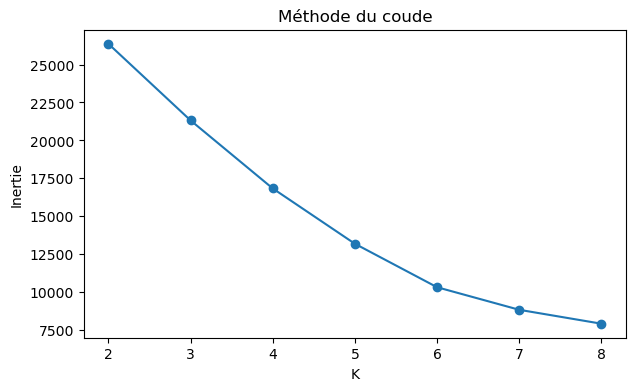

,K,silhouette
0,2,0.9258
1,3,0.4484
2,4,0.4495
3,5,0.4692
4,6,0.4819
5,7,0.4933
6,8,0.5058


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2,9)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xs, labels))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(list(ks), inertias, marker="o")
ax.set_xlabel("K")
ax.set_ylabel("Inertie")
ax.set_title("Méthode du coude")
plt.show()

display(pd.DataFrame({"K":list(ks),"silhouette":silhouettes}).round(4))


# 6. Ajuster K-means et profiler les segments

Ici, on choisit automatiquement le K ayant la meilleure silhouette parmi les valeurs testées pour la démonstration.  
En entreprise, on vérifierait également la stabilité et l’actionnabilité métier.


In [12]:
best_k = list(ks)[int(np.argmax(silhouettes))]
kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=42)
customers["KMeansCluster"] = kmeans.fit_predict(Xs)

print("K retenu pour la démonstration :", best_k)
profile = customers.groupby("KMeansCluster")[feature_cols].median().round(2)
sizes = customers["KMeansCluster"].value_counts().sort_index().rename("n")
display(profile.join(sizes))


K retenu pour la démonstration : 2


,Recency,Frequency,Monetary,AvgBasket,TotalQuantity,ReturnRate,n
KMeansCluster,,,,,,,
0,96.0,3.0,892.46,284.55,487.0,0.00,5859
1,3.0,127.0,144458.37,1374.01,91447.0,0.03,19


### Exemple d’interprétation
Ne dites pas seulement « cluster 0 ».  
Cherchez un profil : récence faible + fréquence élevée + montant élevé peut devenir **clients très actifs / forte valeur**.

Le nom final doit venir des statistiques observées, pas d’une étiquette inventée à l’avance.


# 7. CAH — observer une hiérarchie

La CAH est coûteuse sur plus d’un million de transactions ; nous travaillons donc sur la **table clients**, et nous échantillonnons pour rendre le dendrogramme lisible.


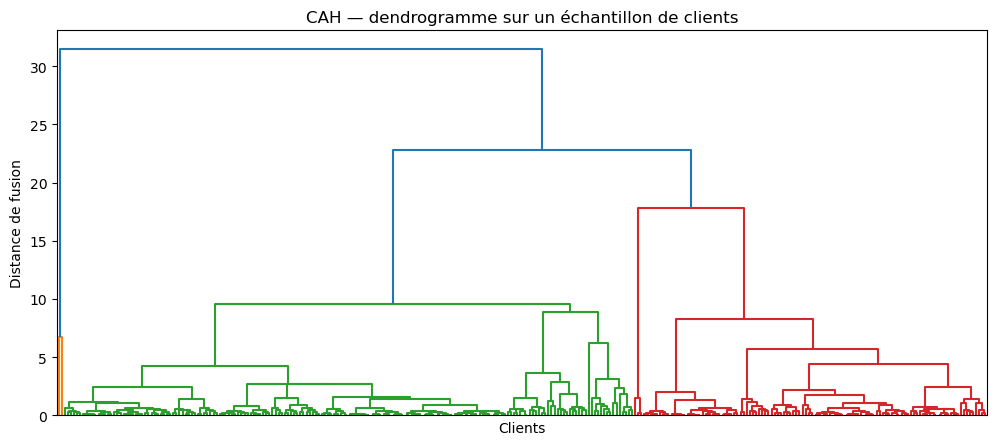

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram

rng = np.random.default_rng(42)
n_sample = min(300, len(customers))
idx = rng.choice(len(customers), size=n_sample, replace=False)
Xs_sample = Xs[idx]

Z = linkage(Xs_sample, method="ward")

plt.figure(figsize=(12,5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("CAH — dendrogramme sur un échantillon de clients")
plt.xlabel("Clients")
plt.ylabel("Distance de fusion")
plt.show()


### À expliquer
Le dendrogramme n’est pas seulement une jolie figure : une coupe horizontale correspond à un choix de granularité des groupes.


# 8. DBSCAN — densité et bruit

DBSCAN ne demande pas K.  
Il cherche des zones denses et marque certains points `-1` comme bruit.

Les paramètres `eps` et `min_samples` sont très sensibles au scaling et à la densité.


In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.0, min_samples=10)
db_labels = db.fit_predict(Xs)

unique, counts = np.unique(db_labels, return_counts=True)
db_summary = pd.DataFrame({"cluster":unique, "n":counts}).sort_values("cluster")
display(db_summary)

noise_rate = np.mean(db_labels == -1)
print("Part de bruit :", round(noise_rate,4))


### Exemple développeur
Dans des logs d’API, DBSCAN peut identifier des comportements denses habituels et laisser comme bruit certaines requêtes très atypiques.  
Mais « bruit » signifie atypique selon les paramètres, pas automatiquement fraude ou incident.


# 9. PCA — réduire la dimension

PCA construit des axes orthogonaux qui capturent le maximum de variance.  
On l’utilise ici pour résumer les six variables comportementales.


,composante,variance_expliquée,variance_cumulée
0,PC1,0.4210,0.4210
1,PC2,0.1903,0.6113
2,PC3,0.1548,0.7661
3,PC4,0.1464,0.9126
4,PC5,0.0669,0.9795
5,PC6,0.0205,1.0000


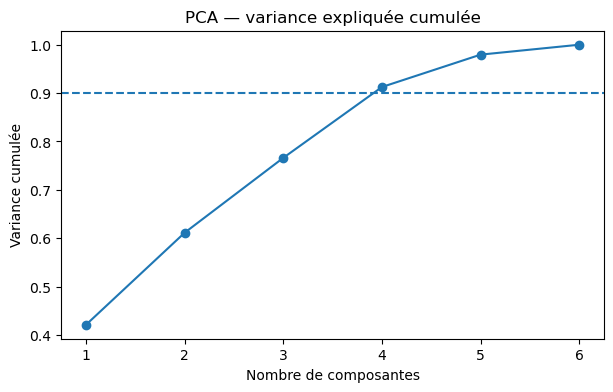

In [14]:
from sklearn.decomposition import PCA

pca = PCA()
Xp = pca.fit_transform(Xs)

explained = pd.DataFrame({
    "composante":[f"PC{i+1}" for i in range(len(feature_cols))],
    "variance_expliquée":pca.explained_variance_ratio_,
    "variance_cumulée":np.cumsum(pca.explained_variance_ratio_)
})
display(explained.round(4))

plt.figure(figsize=(7,4))
plt.plot(range(1,len(feature_cols)+1), explained["variance_cumulée"], marker="o")
plt.axhline(0.90, linestyle="--")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.title("PCA — variance expliquée cumulée")
plt.show()


# 10. Visualiser les clusters dans le plan PCA


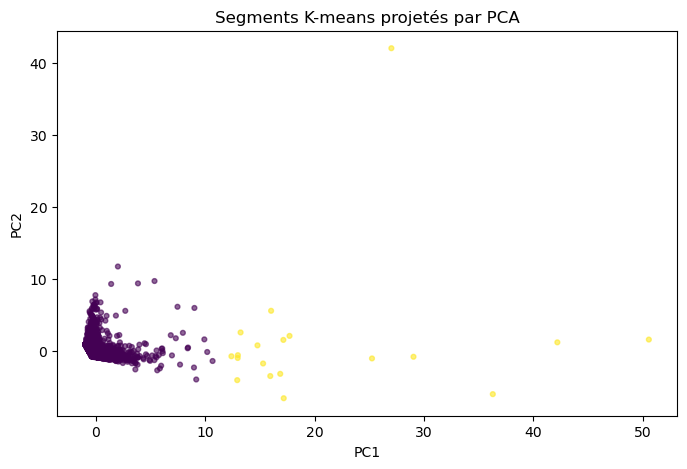

In [15]:
pca2 = PCA(n_components=2)
X2 = pca2.fit_transform(Xs)

plt.figure(figsize=(8,5))
plt.scatter(X2[:,0], X2[:,1], c=customers["KMeansCluster"], s=12, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Segments K-means projetés par PCA")
plt.show()


# 11. t-SNE — visualisation locale

t-SNE est coûteux : nous utilisons un échantillon.  
Il sert à explorer les voisinages locaux ; **ne pas interpréter les distances globales entre îlots comme des distances métriques fiables**.


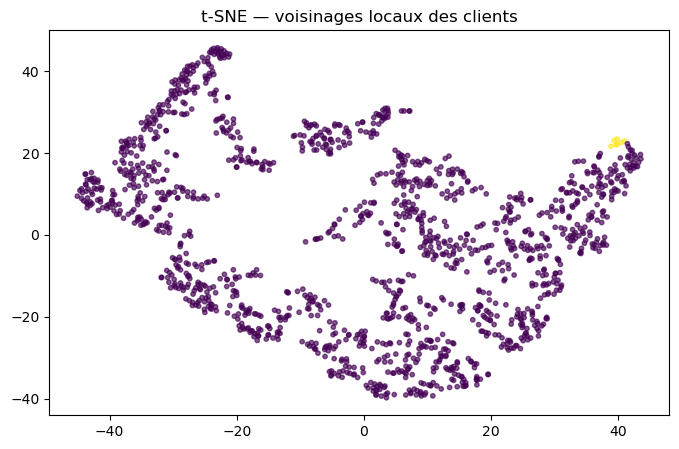

In [16]:
from sklearn.manifold import TSNE

n_tsne = min(1500, len(customers))
idx_tsne = rng.choice(len(customers), size=n_tsne, replace=False)

tsne = TSNE(
    n_components=2, perplexity=30,
    init="pca", learning_rate="auto",
    random_state=42
)
Xt = tsne.fit_transform(Xs[idx_tsne])

plt.figure(figsize=(8,5))
plt.scatter(
    Xt[:,0], Xt[:,1],
    c=customers["KMeansCluster"].to_numpy()[idx_tsne],
    s=10, alpha=0.65
)
plt.title("t-SNE — voisinages locaux des clients")
plt.show()


# 12. Détection d’anomalies — Isolation Forest

Nous cherchons des clients atypiques dans l’espace comportemental.  
Le paramètre `contamination` représente ici une hypothèse de travail pour la démonstration, pas une vérité métier.


In [17]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)
anomaly_label = iso.fit_predict(Xs)
customers["Anomaly"] = anomaly_label == -1
customers["AnomalyScore"] = -iso.score_samples(Xs)

print("Anomalies détectées :", int(customers["Anomaly"].sum()))
display(
    customers.sort_values("AnomalyScore", ascending=False)
    [feature_cols + ["KMeansCluster","AnomalyScore"]]
    .head(15)
    .round(2)
)


Anomalies détectées : 118


,Recency,Frequency,Monetary,AvgBasket,TotalQuantity,ReturnRate,KMeansCluster,AnomalyScore
CustomerID,,,,,,,,
16446.0,1,2,168472.50,84236.25,80997,0.40,1,0.82
18102.0,1,145,608821.65,4198.77,188340,0.01,1,0.82
14646.0,2,151,528602.52,3500.68,367193,0.01,1,0.82
12346.0,326,12,77556.46,6463.04,74285,0.29,0,0.81
14156.0,10,156,313946.37,2012.48,165992,0.02,1,0.80
17450.0,8,51,246973.09,4842.61,84720,0.05,1,0.80
17511.0,3,60,175603.55,2926.73,119656,0.10,1,0.80
14911.0,1,398,295972.63,743.65,149987,0.03,1,0.80
13694.0,4,143,196482.81,1374.01,189205,0.02,1,0.79


### Comment analyser une anomalie ?
Pour chaque cas, demander :
1. quelle variable rend ce client atypique ?
2. est-ce une erreur de données, un gros client, un retour massif, une fraude potentielle ou un comportement légitime ?
3. faut-il exclure, surveiller ou conserver ce cas ?

Un algorithme d’anomalie produit un **signal d’investigation**, pas un verdict.


# 13. Restitution finale des segments

On produit une table compacte permettant de discuter les segments avec un métier.


In [18]:
summary = customers.groupby("KMeansCluster").agg(
    n=("Frequency","size"),
    Recency_med=("Recency","median"),
    Frequency_med=("Frequency","median"),
    Monetary_med=("Monetary","median"),
    AvgBasket_med=("AvgBasket","median"),
    ReturnRate_med=("ReturnRate","median"),
    anomalies=("Anomaly","sum")
).round(2)

display(summary)


,n,Recency_med,Frequency_med,Monetary_med,AvgBasket_med,ReturnRate_med,anomalies
KMeansCluster,,,,,,,
0,5859,96.0,3.0,892.46,284.55,0.00,99
1,19,3.0,127.0,144458.37,1374.01,0.03,19


# SYNTHÈSE APRÈS-MIDI

Workflow complet :

1. partir des transactions réelles ;
2. choisir la bonne granularité : **une ligne par client** ;
3. construire des features comportementales ;
4. scaler ;
5. comparer K-means / CAH / DBSCAN ;
6. évaluer par indices internes + stabilité + sens métier ;
7. utiliser PCA/t-SNE pour explorer la structure ;
8. analyser les anomalies ;
9. transformer les numéros de clusters en **segments interprétables**.

### Question finale
Avec une cible `y` → problème supervisé.  
Sans cible `y` → on cherche une structure dans `X`.

C’est la transition essentielle du Jour 3.
